In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("exoplanet_data.csv", comment="#")

In [3]:
df.shape

(567, 92)

In [4]:
df.columns

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [5]:
list(df.columns[:5])

['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum']

In [27]:
print("Table Label: Planet Name")
print("Database Column Name: pl_name")
print("Description: Planet name most commonly used in the literature.\n")

print("Table Label: Host Name")
print("Database Column Name: hostname")
print("Description: Stellar name most commonly used in the literature\n")

print("Table Label: Discovery Method")
print("Database Column Name: discoverymethod")
print("Description: Method by which the planet was first identified\n")

print("Table Label: Spectral Type")
print("Database Column Name: st_spectype")
print("Description: Classification of the star based on their spectral characteristics following the Morgan-Keenan system\n")

print("Table Label: Equilibrium Temperature [K]")
print("Database Column Name: pl_eqt")
print("Description: The equilibrium temperature of t")

Table Label: Planet Name
Database Column Name: pl_name
Description: Planet name most commonly used in the literature.

Table Label: Host Name
Database Column Name: hostname
Description: Stellar name most commonly used in the literature

Table Label: Discovery Method
Database Column Name: discoverymethod
Description: Method by which the planet was first identified

Table Label: Spectral Type
Database Column Name: st_spectype
Description: Classification of the star based on their spectral characteristics following the Morgan-Keenan system

Table Label: Equilibrium Temperature [K]
Database Column Name: pl_eqt
Description: The equilibrium temperature of t


In [7]:
small_df = df[[
    "pl_name",
    "hostname",
    "discoverymethod",
    "st_spectype",
    "pl_eqt",
    "pl_bmassj"
]]


In [8]:
clean_df = small_df.dropna()

In [9]:
clean_df.shape

(67, 6)

In [10]:
rows, cols = clean_df.shape
print("Rows =", rows)
print("Columns =", cols)

Rows = 67
Columns = 6


In [11]:
clean_df.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [12]:
clean_df.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
546,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
549,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
555,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
561,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
566,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [13]:
clean_df.columns

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')

In [14]:
clean_df["discoverymethod"].value_counts()

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

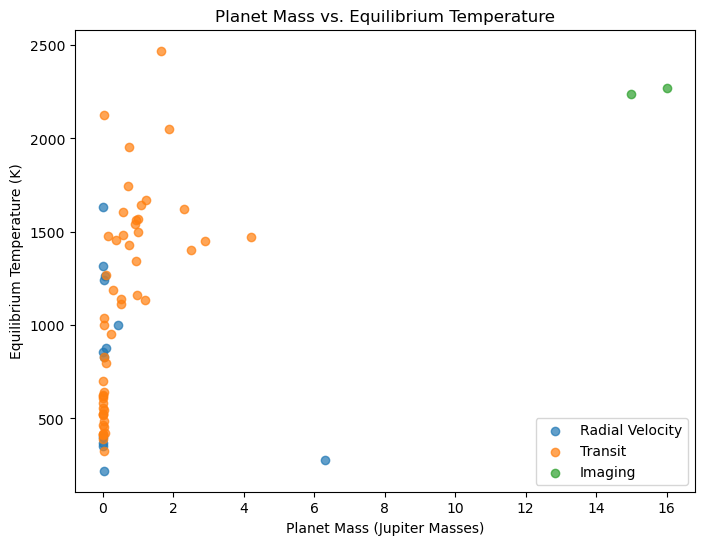

In [15]:
plt.figure(figsize=(8, 6))

methods = clean_df["discoverymethod"].unique()

for method in methods:
    subset = clean_df[clean_df["discoverymethod"] == method]
    plt.scatter(
        subset["pl_bmassj"],
        subset["pl_eqt"],         
        label=method,             
        alpha=0.7                 
    )

plt.title("Planet Mass vs. Equilibrium Temperature")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")

plt.legend()

plt.show()

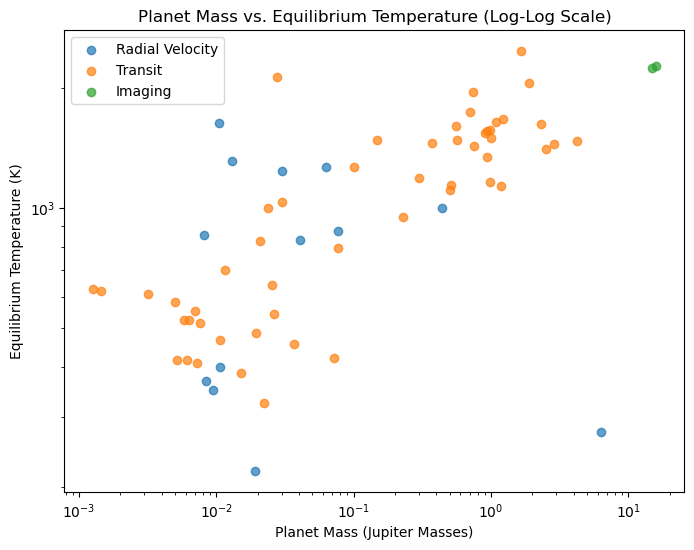

In [16]:
plt.figure(figsize=(8, 6))

methods = clean_df["discoverymethod"].unique()

for method in methods:
    subset = clean_df[clean_df["discoverymethod"] == method]
    plt.scatter(
        subset["pl_bmassj"],
        subset["pl_eqt"],
        label=method,
        alpha=0.7
    )

plt.xscale("log")
plt.yscale("log")

plt.title("Planet Mass vs. Equilibrium Temperature (Log-Log Scale)")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend()
plt.show()


In [17]:
massive_planets = clean_df[clean_df["pl_bmassj"] > 5]

In [18]:
coldest_row = massive_planets.loc[massive_planets["pl_eqt"].idxmin()]

In [19]:
coldest_row

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 566, dtype: object

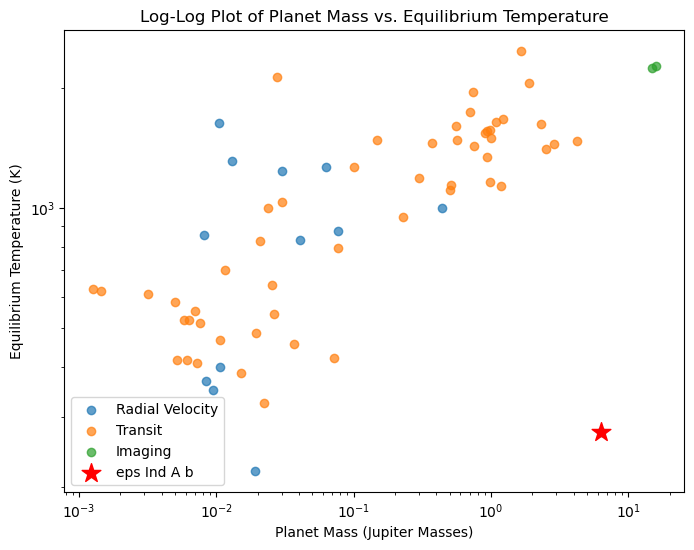

In [20]:
plt.figure(figsize=(8, 6))

methods = clean_df["discoverymethod"].unique()


for method in methods:
    subset = clean_df[clean_df["discoverymethod"] == method]
    plt.scatter(
        subset["pl_bmassj"],
        subset["pl_eqt"],
        alpha=0.7,
        label=method
    )


plt.scatter(
    coldest_row["pl_bmassj"],
    coldest_row["pl_eqt"],
    color="red",        # different color
    marker="*",         # star marker
    s=200,              # larger size
    label=coldest_row["pl_name"]   # add name to legend
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.title("Log-Log Plot of Planet Mass vs. Equilibrium Temperature")

plt.legend()
plt.show()